# EDA Fraud Data


In [5]:
import pandas as pd
import numpy as np

raw = pd.read_csv("../data/raw/Fraud_Data.csv")
ip_map = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

# 1) Duplicates
print("Fraud_Data duplicates:", raw.duplicated().sum())
raw = raw.drop_duplicates()

# 2) Dtypes (timestamps)
raw["signup_time"] = pd.to_datetime(raw["signup_time"], errors="coerce")
raw["purchase_time"] = pd.to_datetime(raw["purchase_time"], errors="coerce")

# 3) Missing values summary
missing = raw.isna().mean().sort_values(ascending=False)
display(missing[missing > 0])

# Example handling:
for c in ["source", "browser", "sex"]:
    if c in raw.columns:
        raw[c] = raw[c].fillna("Unknown")

for c in ["age", "purchase_value"]:
    if c in raw.columns:
        raw[c] = pd.to_numeric(raw[c], errors="coerce")
        raw[c] = raw[c].fillna(raw[c].median())

raw.info()


Fraud_Data duplicates: 0


Series([], dtype: float64)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[ns]
 2   purchase_time   151112 non-null  datetime64[ns]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  object        
 5   source          151112 non-null  object        
 6   browser         151112 non-null  object        
 7   sex             151112 non-null  object        
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(4), object(4)
memory usage: 12.7+ MB


(151112, 23)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,...,upper_bound_ip_address,country,time_since_signup_sec,hour_of_day,day_of_week,is_weekend,negative_time_since_signup,user_txn_count_1h,user_txn_count_24h,user_txn_index
0,2,2015-01-11 03:47:13,2015-02-21 10:03:37,54,FGBQNDNBETFJJ,SEO,Chrome,F,25,8.802175e+08,...,8.891924e+08,United States,3564984.0,10,5,1,0,1.0,1.0,0
1,4,2015-06-02 16:40:57,2015-09-26 21:32:16,41,MKFUIVOHLJBYN,Direct,Safari,F,38,2.785906e+09,...,2.786066e+09,Switzerland,10039879.0,21,5,1,0,1.0,1.0,0
2,8,2015-05-28 07:53:06,2015-08-13 11:53:07,47,SCQGQALXBUQZJ,SEO,Chrome,M,25,3.560567e+08,...,3.690988e+08,United States,6667201.0,11,3,0,0,1.0,1.0,0
3,9,2015-05-16 15:58:32,2015-05-20 23:06:42,62,IEZOHXPZBIRTE,SEO,FireFox,M,21,7.591047e+08,...,7.570719e+08,Unknown,371290.0,23,2,0,0,1.0,1.0,0
4,12,2015-01-10 06:25:12,2015-03-04 20:56:37,35,MSNWCFEHKTIOY,Ads,Safari,M,19,2.985180e+09,...,2.985296e+09,Mexico,4631485.0,20,2,0,0,1.0,1.0,0


class
0    136961
1     14151
Name: count, dtype: int64
Fraud rate: 0.09364577267192546


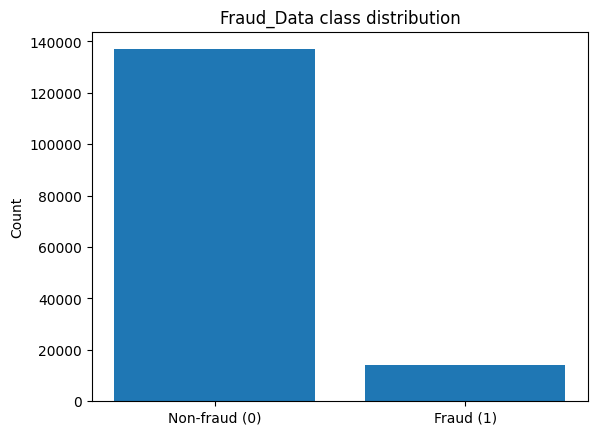

negative_time_since_signup: 0


In [6]:
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/fraud_ecommerce.parquet")
print(df.shape)
display(df.head())

# Class imbalance
print(df["class"].value_counts())
print("Fraud rate:", df["class"].mean())

# Plot
counts = df["class"].value_counts().sort_index()
plt.figure()
plt.bar(["Non-fraud (0)", "Fraud (1)"], counts.values)
plt.title("Fraud_Data class distribution")
plt.ylabel("Count")
plt.show()

# Negative time_since_signup
print("negative_time_since_signup:", df["negative_time_since_signup"].sum())


In [7]:
country_stats = (
    df.groupby("country")["class"]
      .agg(txn_count="count", fraud_rate="mean")
      .sort_values(["fraud_rate","txn_count"], ascending=[False, False])
)
country_stats = country_stats[country_stats["txn_count"] >= 100]
display(country_stats.head(15))


,txn_count,fraud_rate
country,,
Ecuador,106,0.264151
Tunisia,118,0.262712
Peru,119,0.260504
Ireland,240,0.229167
New Zealand,278,0.223022
Saudi Arabia,264,0.189394
Denmark,490,0.159184
Chile,417,0.153477
Greece,231,0.142857


In [8]:
for col in ["source", "browser", "sex"]:
    tab = (
        df.groupby(col)["class"]
          .agg(txn_count="count", fraud_rate="mean")
          .sort_values("fraud_rate", ascending=False)
    )
    print("\n==", col, "==")
    display(tab.head(10))



== source ==


,txn_count,fraud_rate
source,,
Direct,30616,0.105370
Ads,59881,0.092066
SEO,60615,0.089285



== browser ==


,txn_count,fraud_rate
browser,,
Chrome,61432,0.098792
FireFox,24610,0.095165
Safari,24667,0.090201
Opera,3676,0.089227
IE,36727,0.086775



== sex ==


,txn_count,fraud_rate
sex,,
M,88293,0.095523
F,62819,0.091007


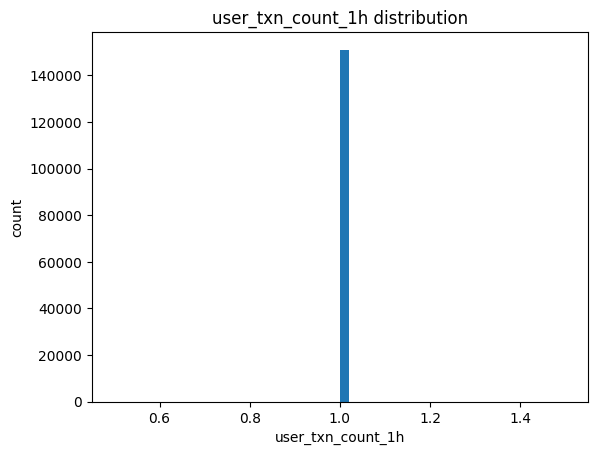

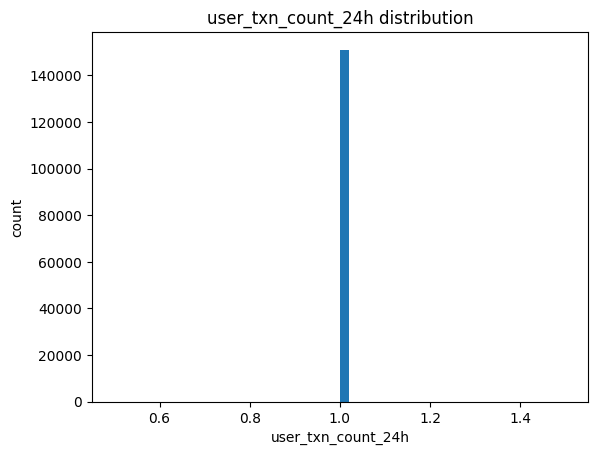

In [9]:
for c in ["user_txn_count_1h", "user_txn_count_24h"]:
    plt.figure()
    plt.hist(df[c], bins=50)
    plt.title(f"{c} distribution")
    plt.xlabel(c)
    plt.ylabel("count")
    plt.show()
